# Feature Scaling: Normalization vs Standardization

## The Foundation of ML Performance 🚀

### Why is it important?
When features have different scales, ML algorithms get confused! 
- Age: 20-80
- Salary: 20,000-200,000

**Without scaling**: Model thinks salary is 1000x more important than age!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.datasets import make_classification
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. The Problem: Different Scales

📊 Original Data Statistics:

              Age         Salary  Experience
count  100.000000     100.000000  100.000000
mean    49.580000  108555.230000   20.070000
std     18.031499   51432.346507   12.305255
min     21.000000   21016.000000    0.000000
25%     34.000000   60173.750000    9.500000
50%     48.000000  114342.500000   21.500000
75%     66.000000  148610.000000   31.000000
max     79.000000  199997.000000   39.000000


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_71095/3963249449.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


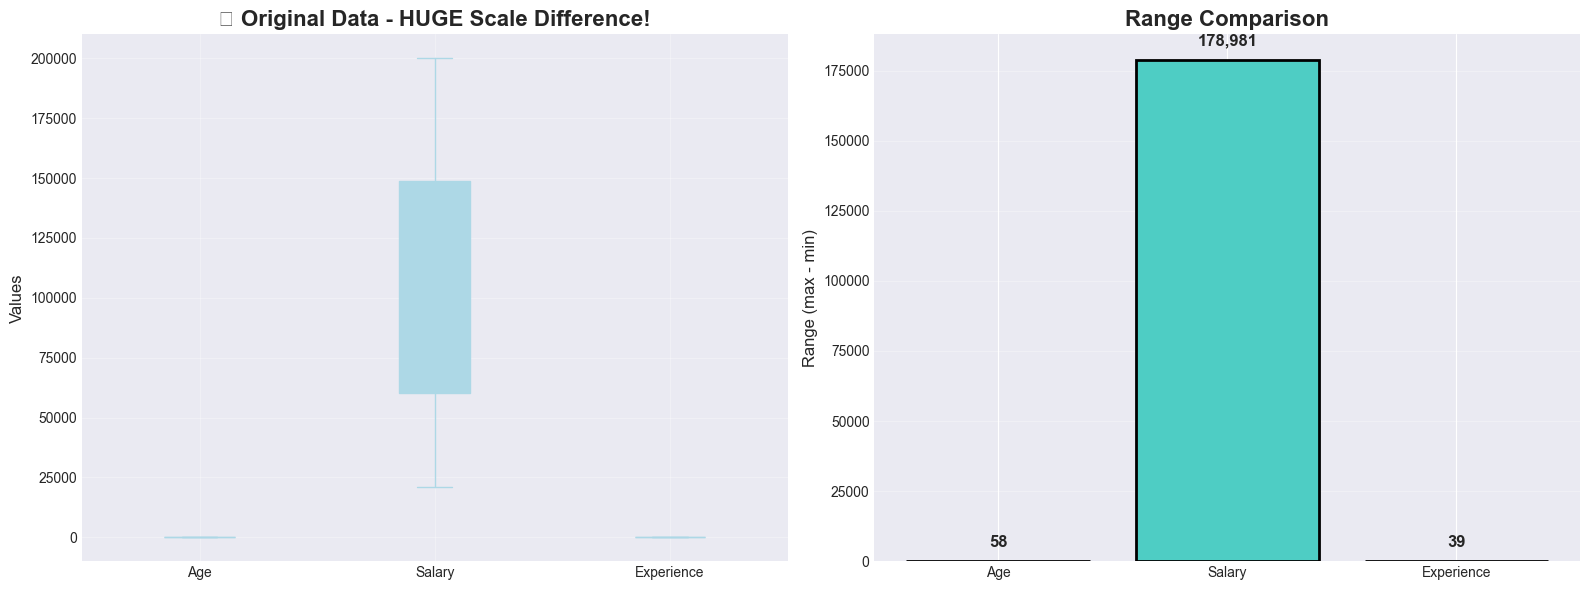


⚠️ PROBLEM: Salary dominates! ML model will ignore Age and Experience!


In [2]:
# Create sample data with different scales
np.random.seed(42)
n_samples = 100

# Features with VERY different scales
age = np.random.randint(20, 80, n_samples)  # 20-80
salary = np.random.randint(20000, 200000, n_samples)  # 20K-200K
years_experience = np.random.randint(0, 40, n_samples)  # 0-40

# Create DataFrame
data = pd.DataFrame({
    'Age': age,
    'Salary': salary,
    'Experience': years_experience
})

print("📊 Original Data Statistics:\n")
print(data.describe())

# Visualize the problem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
data.plot(kind='box', ax=ax1, color='lightblue', patch_artist=True)
ax1.set_title('❌ Original Data - HUGE Scale Difference!', fontsize=16, weight='bold')
ax1.set_ylabel('Values', fontsize=12)
ax1.grid(True, alpha=0.3)

# Bar plot of ranges
ranges = data.max() - data.min()
ax2.bar(data.columns, ranges, color=['#FF6B6B', '#4ECDC4', '#95E1D3'], 
        edgecolor='black', linewidth=2)
ax2.set_title('Range Comparison', fontsize=16, weight='bold')
ax2.set_ylabel('Range (max - min)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, (col, val) in enumerate(ranges.items()):
    ax2.text(i, val + 5000, f'{val:,.0f}', ha='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ PROBLEM: Salary dominates! ML model will ignore Age and Experience!")

## 2. Normalization (Min-Max Scaling)

### Formula: $X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$

**Result:** All values between [0, 1]

**When to use:**
- ✅ Neural Networks
- ✅ Image processing (pixels 0-255)
- ✅ When you know the bounds
- ❌ Sensitive to outliers!

📊 Normalized Data Statistics:

              Age      Salary  Experience
count  100.000000  100.000000  100.000000
mean     0.492759    0.489098    0.514615
std      0.310888    0.287362    0.315519
min      0.000000    0.000000    0.000000
25%      0.224138    0.218782    0.243590
50%      0.465517    0.521432    0.551282
75%      0.775862    0.712891    0.794872
max      1.000000    1.000000    1.000000


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_71095/2181151193.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


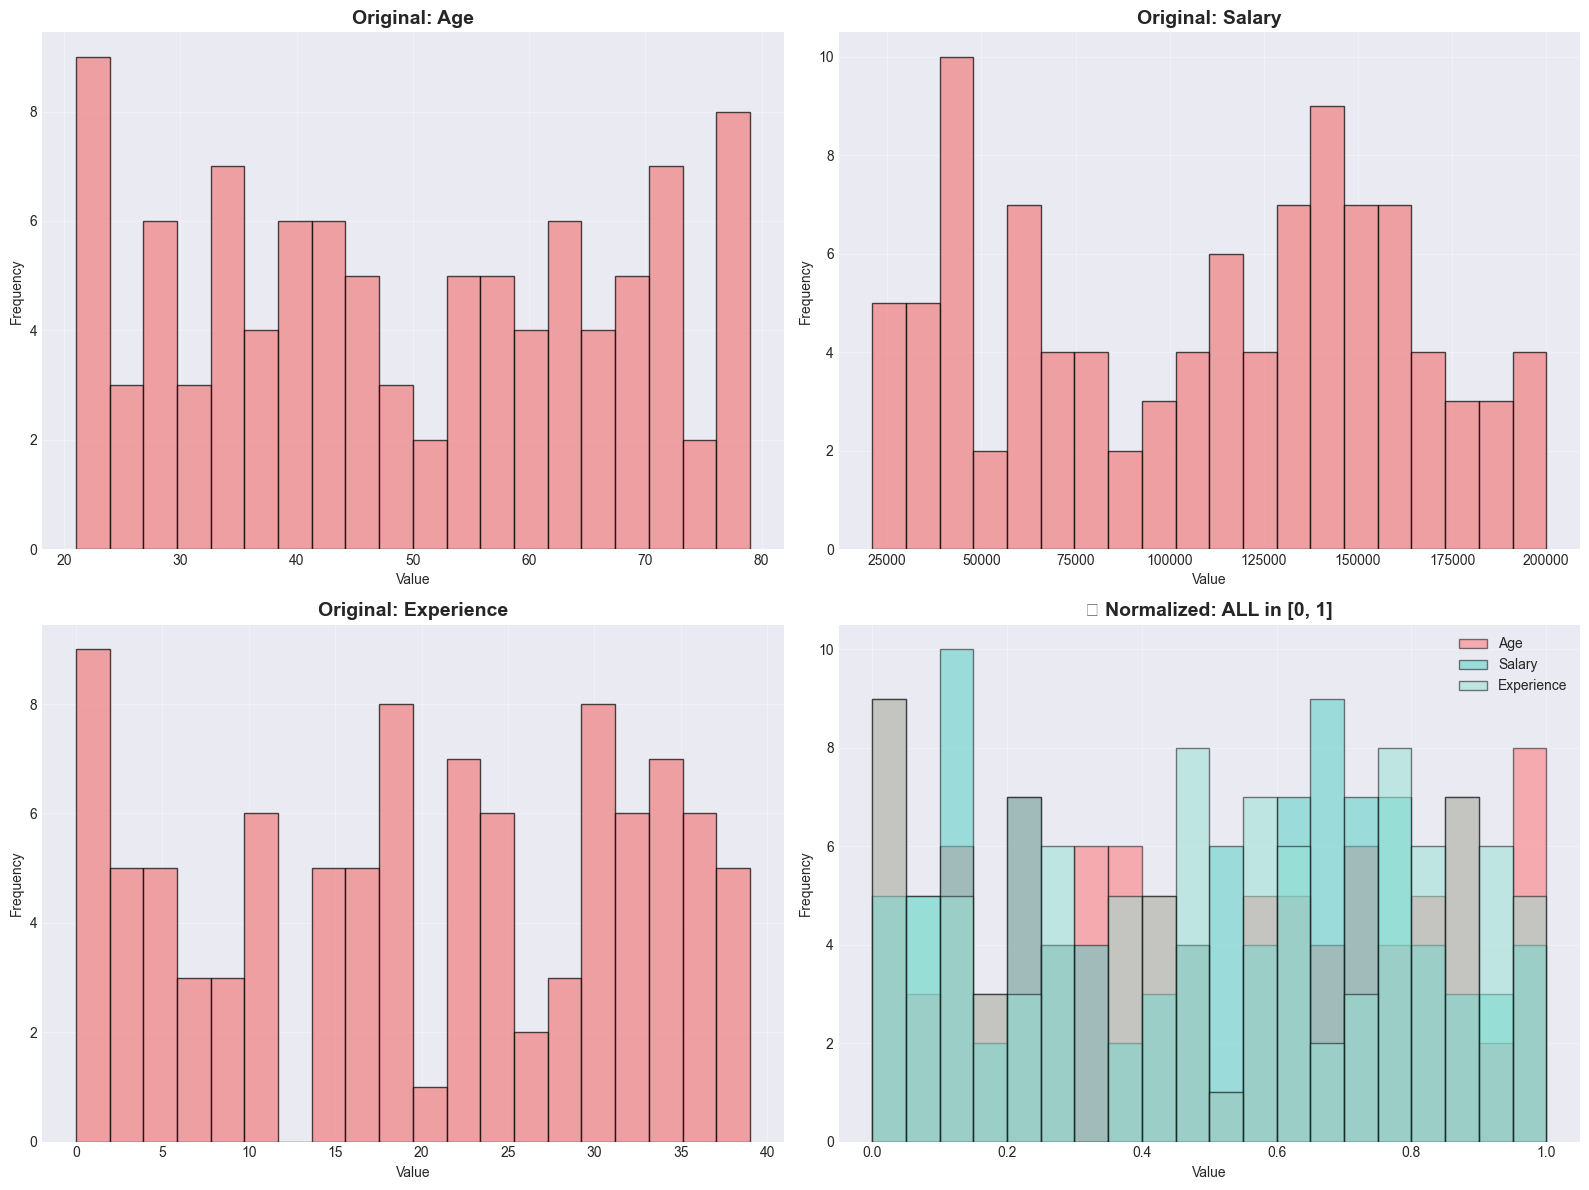


✅ SUCCESS: All features now between 0 and 1!
   No feature dominates others!


In [3]:
# Apply Min-Max Scaling
scaler_minmax = MinMaxScaler()
data_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(data),
    columns=data.columns
)

print("📊 Normalized Data Statistics:\n")
print(data_normalized.describe())

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original distributions
for i, col in enumerate(data.columns):
    ax = axes[0, i] if i < 2 else axes[1, 0]
    data[col].hist(bins=20, ax=ax, color='lightcoral', edgecolor='black', alpha=0.7)
    ax.set_title(f'Original: {col}', fontsize=14, weight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Normalized (all on same scale!)
ax = axes[1, 1]
for col, color in zip(data_normalized.columns, ['#FF6B6B', '#4ECDC4', '#95E1D3']):
    data_normalized[col].hist(bins=20, ax=ax, alpha=0.5, label=col, 
                               color=color, edgecolor='black')
ax.set_title('✅ Normalized: ALL in [0, 1]', fontsize=14, weight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ SUCCESS: All features now between 0 and 1!")
print("   No feature dominates others!")

## 3. Standardization (Z-score Scaling)

### Formula: $X_{std} = \frac{X - \mu}{\sigma}$

Where:
- $\mu$ = mean
- $\sigma$ = standard deviation

**Result:** Mean = 0, Std = 1

**When to use:**
- ✅ Most ML algorithms (SVM, Linear Regression, Logistic Regression)
- ✅ When data has Gaussian distribution
- ✅ Less sensitive to outliers (compared to normalization)
- ✅ PCA, clustering algorithms

/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_71095/3525222616.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


📊 Standardized Data Statistics:

                Age        Salary    Experience
count  1.000000e+02  1.000000e+02  1.000000e+02
mean   9.325873e-17  4.996004e-17 -1.998401e-17
std    1.005038e+00  1.005038e+00  1.005038e+00
min   -1.592989e+00 -1.710601e+00 -1.639227e+00
25%   -8.683964e-01 -9.454209e-01 -8.633100e-01
50%   -8.806588e-02  1.130889e-01  1.167960e-01
75%    9.152163e-01  7.827090e-01  8.927132e-01
max    1.639809e+00  1.786861e+00  1.546117e+00


/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


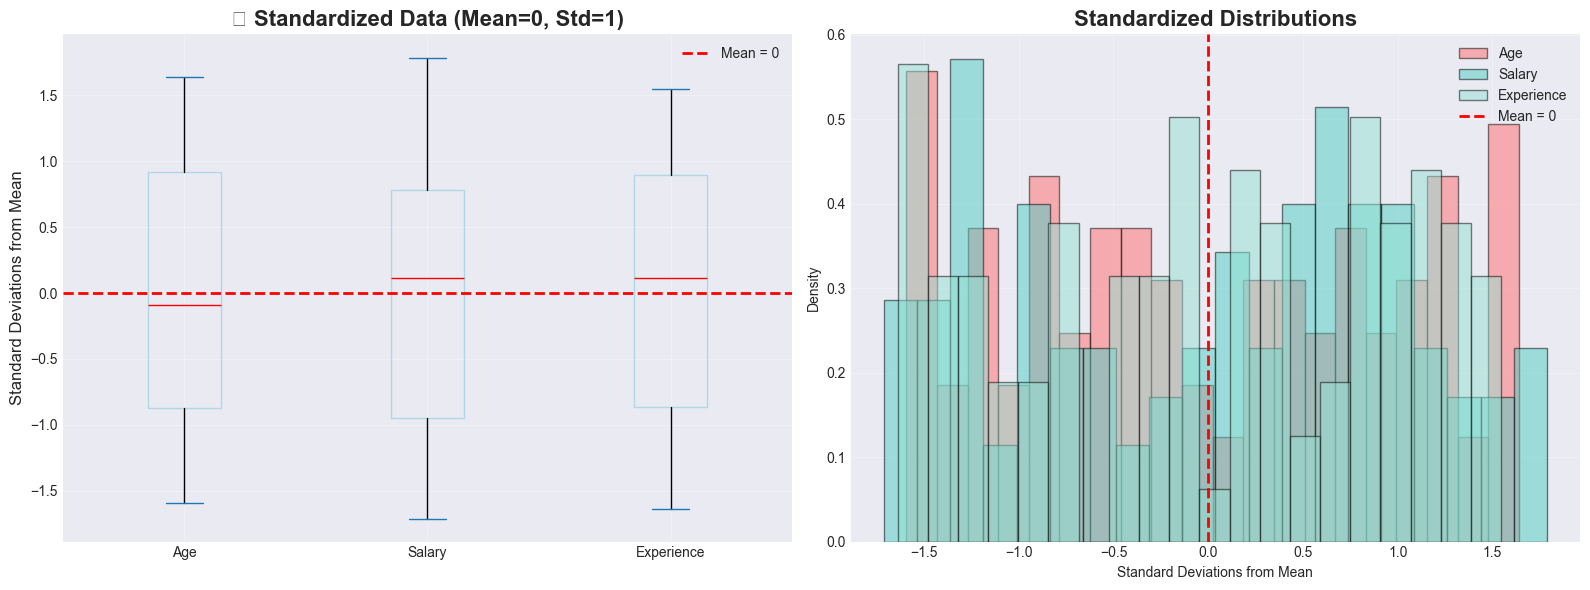


✅ SUCCESS: All features centered at 0 with standard deviation of 1!
   Perfect for most ML algorithms!


In [4]:
# Apply Standardization
scaler_standard = StandardScaler()
data_standardized = pd.DataFrame(
    scaler_standard.fit_transform(data),
    columns=data.columns
)

print("📊 Standardized Data Statistics:\n")
print(data_standardized.describe())

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot comparison
data_standardized.plot(kind='box', ax=ax1, 
                       color=dict(boxes='lightblue', whiskers='black', medians='red'))
ax1.set_title('✅ Standardized Data (Mean=0, Std=1)', fontsize=16, weight='bold')
ax1.set_ylabel('Standard Deviations from Mean', fontsize=12)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Mean = 0')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Overlapping distributions
for col, color in zip(data_standardized.columns, ['#FF6B6B', '#4ECDC4', '#95E1D3']):
    data_standardized[col].hist(bins=20, ax=ax2, alpha=0.5, label=col,
                                color=color, edgecolor='black', density=True)
ax2.set_title('Standardized Distributions', fontsize=16, weight='bold')
ax2.set_xlabel('Standard Deviations from Mean')
ax2.set_ylabel('Density')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean = 0')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ SUCCESS: All features centered at 0 with standard deviation of 1!")
print("   Perfect for most ML algorithms!")

## 4. Side-by-Side Comparison

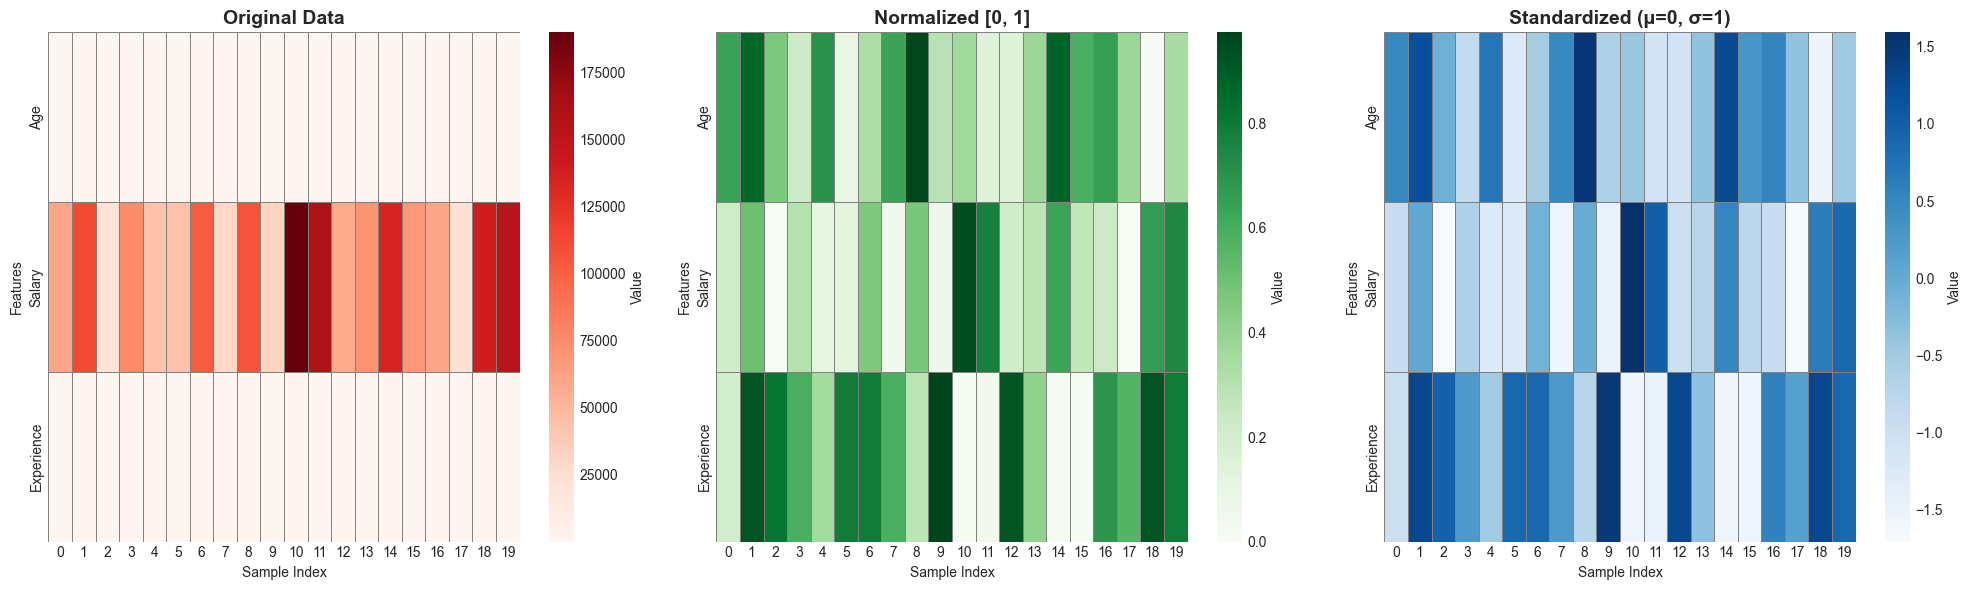


🎨 Heatmap Comparison:
   Original: Salary dominates (dark red)
   Normalized: All features visible equally!
   Standardized: Centered, comparable scales!


In [5]:
# Compare all three
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = [
    (data, 'Original Data', 'Reds'),
    (data_normalized, 'Normalized [0, 1]', 'Greens'),
    (data_standardized, 'Standardized (μ=0, σ=1)', 'Blues')
]

for ax, (df, title, cmap) in zip(axes, datasets):
    # Heatmap of first 20 samples
    sns.heatmap(df.head(20).T, cmap=cmap, ax=ax, cbar_kws={'label': 'Value'},
               linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Features')

plt.tight_layout()
plt.show()

print("\n🎨 Heatmap Comparison:")
print("   Original: Salary dominates (dark red)")
print("   Normalized: All features visible equally!")
print("   Standardized: Centered, comparable scales!")

## 5. Handling Outliers: Robust Scaler

### Formula: $X_{robust} = \frac{X - median}{IQR}$

Where IQR = Interquartile Range (75th percentile - 25th percentile)

**Best for data with outliers!**

📊 Data WITH Outliers:

   Age  Salary  Experience
0   58  500000           8
1   71  600000          36
2   48  550000          32
3   34  580000          23
4   62  620000          14
5   27  590000          31
6   40  102798          31
7   58   29268          23
8   77  106807          11
9   38   32185          38


ValueError: Invalid RGBA argument: 'lightco'

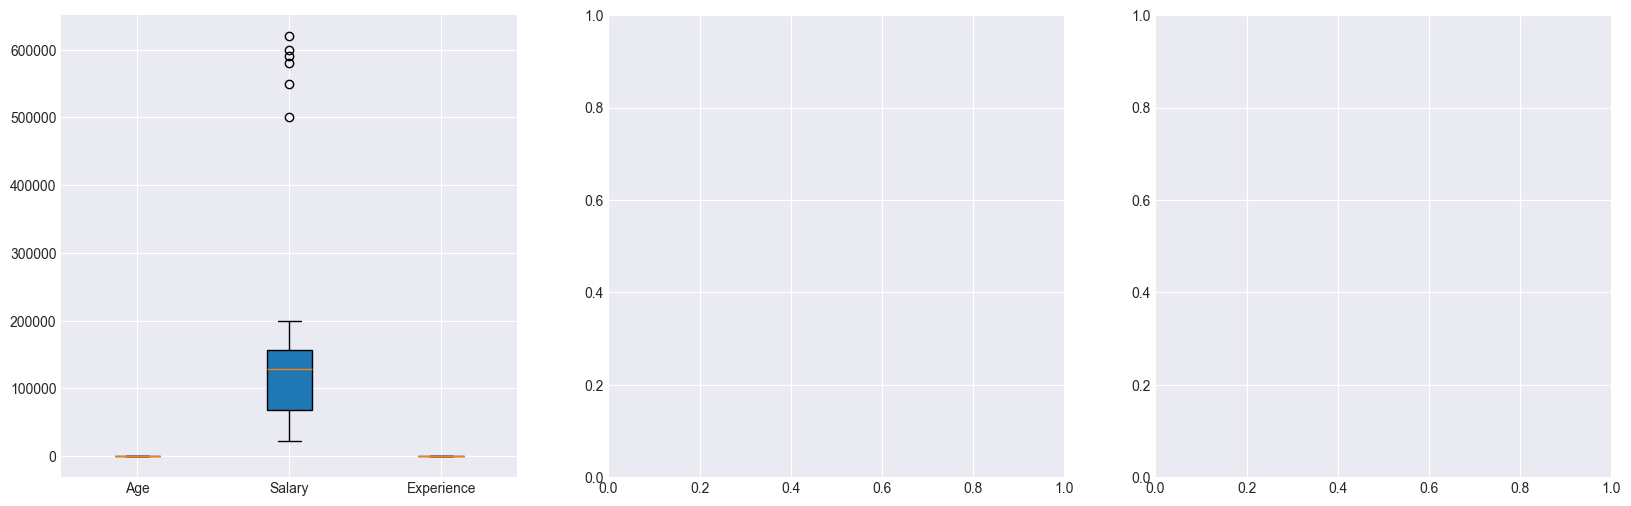

In [6]:
# Add outliers to salary
data_with_outliers = data.copy()
data_with_outliers.loc[0:5, 'Salary'] = [500000, 600000, 550000, 580000, 620000, 590000]

print("📊 Data WITH Outliers:\n")
print(data_with_outliers.head(10))

# Apply different scalers
scaler_minmax_out = MinMaxScaler()
scaler_robust = RobustScaler()

data_minmax_out = pd.DataFrame(
    scaler_minmax_out.fit_transform(data_with_outliers),
    columns=data.columns
)

data_robust = pd.DataFrame(
    scaler_robust.fit_transform(data_with_outliers),
    columns=data.columns
)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Original with outliers
data_with_outliers.boxplot(ax=axes[0], color='lightcoral', patch_artist=True)
axes[0].set_title('❌ Original (With Outliers)', fontsize=14, weight='bold')
axes[0].set_ylabel('Value')

# MinMax with outliers
data_minmax_out.boxplot(ax=axes[1], color='orange', patch_artist=True)
axes[1].set_title('⚠️ MinMax Scaler (Affected by Outliers)', fontsize=14, weight='bold')
axes[1].set_ylabel('Scaled Value')

# Robust scaler
data_robust.boxplot(ax=axes[2], color='lightgreen', patch_artist=True)
axes[2].set_title('✅ Robust Scaler (Handles Outliers)', fontsize=14, weight='bold')
axes[2].set_ylabel('Scaled Value')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Notice: Robust Scaler handles outliers much better!")
print("   MinMax gets compressed by extreme values.")

## 6. Decision Guide: Which Scaler to Use?

### Quick Reference Table:

In [ ]:
# Create decision table
decision_data = {
    'Scaler': ['Min-Max\nNormalization', 'Standard\nScaling', 'Robust\nScaling'],
    'Output Range': ['[0, 1]', 'Unbounded\n(mean=0, std=1)', 'Unbounded\n(median=0)'],
    'Sensitive to\nOutliers': ['YES ❌', 'Somewhat ⚠️', 'NO ✅'],
    'Best For': ['Neural Networks\nImage Data', 'Linear Models\nSVM, Logistic Reg', 'Data with\nOutliers'],
}

df_decision = pd.DataFrame(decision_data)

# Visualize as table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_decision.values, colLabels=df_decision.columns,
                cellLoc='center', loc='center',
                colColours=['#4ECDC4']*4,
                cellColours=[['#FFE5E5', '#E5F9FF', '#E5FFE5']]*4)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.title('🎯 Feature Scaling Decision Guide', fontsize=16, weight='bold', pad=20)
plt.show()

print("\n📋 Quick Rules:")
print("   1. Neural Networks → Min-Max Normalization")
print("   2. Linear Models (SVM, LogReg) → Standardization")
print("   3. Data with outliers → Robust Scaling")
print("   4. Tree-based models (Random Forest, XGBoost) → NO SCALING NEEDED!")

## 7. Real Impact on ML Performance

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create classification dataset with different scales
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                          n_informative=2, n_clusters_per_class=1, 
                          random_state=42, flip_y=0.1)

# Make features have different scales
X[:, 0] = X[:, 0] * 100  # Feature 1: -300 to 300
X[:, 1] = X[:, 1] * 1    # Feature 2: -3 to 3

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train WITHOUT scaling
svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(X_train, y_train)
acc_no_scale = accuracy_score(y_test, svm_no_scale.predict(X_test))

# Train WITH scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_with_scale = SVC(kernel='rbf', random_state=42)
svm_with_scale.fit(X_train_scaled, y_train)
acc_with_scale = accuracy_score(y_test, svm_with_scale.predict(X_test_scaled))

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Original data scatter
scatter1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                      cmap='RdYlGn', s=100, edgecolor='black', alpha=0.7)
ax1.set_title('Original Data (Different Scales)', fontsize=14, weight='bold')
ax1.set_xlabel('Feature 1 (scale: -300 to 300)')
ax1.set_ylabel('Feature 2 (scale: -3 to 3)')
ax1.grid(True, alpha=0.3)

# Scaled data scatter
scatter2 = ax2.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train,
                      cmap='RdYlGn', s=100, edgecolor='black', alpha=0.7)
ax2.set_title('Scaled Data (Same Scale)', fontsize=14, weight='bold')
ax2.set_xlabel('Feature 1 (standardized)')
ax2.set_ylabel('Feature 2 (standardized)')
ax2.grid(True, alpha=0.3)

# Accuracy comparison
accuracies = [acc_no_scale * 100, acc_with_scale * 100]
colors = ['red', 'green']
labels = ['Without\nScaling', 'With\nScaling']

bars = ax3.bar(labels, accuracies, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=2, width=0.5)
ax3.set_ylabel('Accuracy (%)', fontsize=12, weight='bold')
ax3.set_title('SVM Accuracy Comparison', fontsize=14, weight='bold')
ax3.set_ylim([0, 100])
ax3.grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar, val in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'{val:.1f}%', ha='center', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

improvement = acc_with_scale - acc_no_scale
print("\n" + "="*60)
print("🎯 PERFORMANCE IMPACT")
print("="*60)
print(f"\n❌ Without Scaling: {acc_no_scale*100:.1f}% accuracy")
print(f"✅ With Scaling:    {acc_with_scale*100:.1f}% accuracy")
print(f"\n📈 Improvement:     +{improvement*100:.1f}%")
print("\n💡 Feature scaling can dramatically improve model performance!")
print("="*60)

---
# 🎯 FINAL SUMMARY

## Key Takeaways:

### 1. **Why Scale?**
- Features with different scales confuse ML algorithms
- Large-scale features dominate small-scale ones
- Affects distance-based algorithms most (KNN, SVM, K-Means)

### 2. **Three Main Techniques:**

#### **Min-Max Normalization**
```python
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
```
- Range: [0, 1]
- Use: Neural networks, image data
- ⚠️ Sensitive to outliers

#### **Standardization (Z-score)**
```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```
- Mean: 0, Std: 1
- Use: Most ML algorithms (SVM, Linear Models)
- ✅ Most commonly used

#### **Robust Scaling**
```python
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
```
- Uses median and IQR
- Use: Data with outliers
- ✅ Most robust

### 3. **When NOT to Scale:**
- ❌ Tree-based models (Random Forest, XGBoost, Decision Trees)
- ❌ Already normalized data (like probabilities)

### 4. **Important Rules:**
1. **Always** fit scaler on training data only!
   ```python
   scaler.fit(X_train)  # Learn parameters from train
   X_train_scaled = scaler.transform(X_train)
   X_test_scaled = scaler.transform(X_test)  # Apply same transformation
   ```
2. **Never** fit on test data (data leakage!)
3. **Always** scale before PCA or clustering

### 5. **Quick Decision Tree:**
```
Has outliers?
├─ YES → Use RobustScaler
└─ NO
   ├─ Neural Network? → MinMaxScaler
   ├─ SVM/Linear Model? → StandardScaler
   └─ Tree-based? → No scaling needed
```

---

## 🚀 Remember:
**Feature scaling is often the difference between a model that works and one that doesn't!**

It's a simple preprocessing step that can boost accuracy by 10-30% in many cases.

**Always experiment with different scalers to see what works best for your data!**